**Creazione e setup del database**

In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

#caricamento
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)

#Iniezione manuale di rumore : 5 valori nulli e 3 outlier

np.random.seed(42)
df.iloc[np.random.randint(0,150,5), 0]= np.nan #Valori mancanti

df.iloc[0, :] = [20.0, 15.0, 30.0, 10.0] #Outlier estremo 1
df.iloc[50, :] = [0.1, 0.1, 0.1, 0.1]    #Outlier estremo 2

print("Dataset caricato. Prime righe con potenziali problemi:")
print(df.head())

Dataset caricato. Prime righe con potenziali problemi:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0               20.0              15.0               30.0              10.0
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


**Data Cleaning**

Ora che il dataset è pronto (e problematico), dobbiamo procedere con la pulizia. Nel Data Mining, non possiamo passare dati NaN (Not a Number) agli algoritmi di PCA o Clustering, perché manderebbero in crash i calcoli matematici.

In [3]:
#Primo passo: Controllo valori nulli
print("\nValori nulli per colonna:\n", df.isnull().sum())

#Strategia: Imputazione con la media (Best Practice per piccoli dataset)
df_cleaned = df.fillna(df.mean())

print("\nPulizia completata. Valori nulli residui:", df_cleaned.isnull().sum().sum())


Valori nulli per colonna:
 sepal length (cm)    5
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

Pulizia completata. Valori nulli residui: 0


In [4]:
#Secondo passo: Standardizzazione, dobbiamo riportare tutti i valori su una scala uniforme in modo che nessuno prevalga
#Utilizziamo lo Z-score

scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_cleaned)

#Trasformiamo in Dataframe per comodita'
df_scaled = pd.DataFrame(data_scaled, columns=df.columns)

In [5]:
#Terzo passo: Riduzione della dimensionalita', utilizzeremo la PCA, passando da 4 dimensioni a 2

pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

print(f"\nVarianza mantenuta con 2 componenti: {np.sum(pca.explained_variance_ratio_):.2%}")


Varianza mantenuta con 2 componenti: 97.76%


**Outlier Analysis**

Adesso procederemo ad analizzare gli outlier 

In [6]:
#Cerchiamo circa il 5% di outlier

iso_forest = IsolationForest(contamination=0.05, random_state=42)
outliers = iso_forest.fit_predict(data_pca) #Usiamo i dati PCA per ridurre il rumore 

#Aggiungiamo il risultato al nostro DataFrame PCA
df_results = pd.DataFrame(data_pca, columns=['PC1', 'PC2'])
df_results['is_outlier'] = outliers #-1 e' outlier, 1 e' normale

print("\nNumero di outlier rilevati:", (df_results['is_outlier'] == -1).sum())
print("Indici degli outlier:", df_results.index[df_results['is_outlier'] == -1].tolist())


Numero di outlier rilevati: 8
Indici degli outlier: [0, 15, 32, 41, 50, 117, 118, 131]


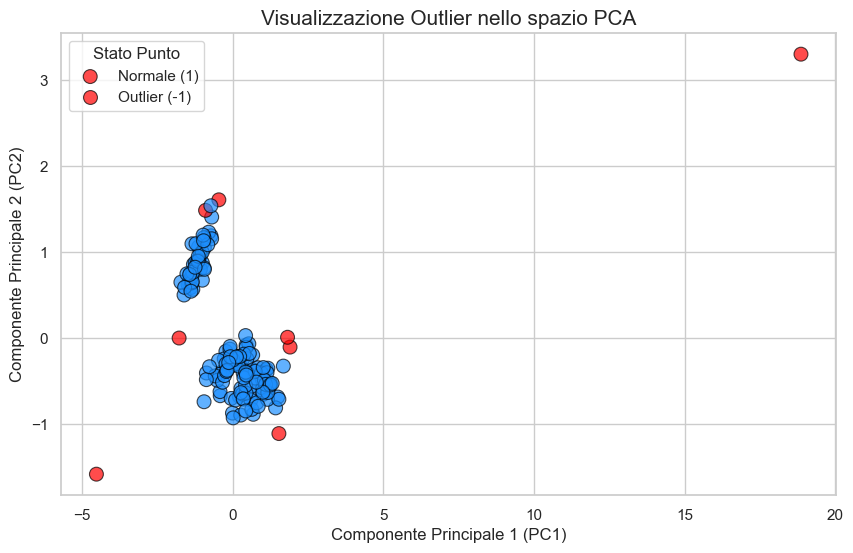

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Impostiamo lo stile
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Creiamo lo scatter plot usando i componenti della PCA
# Coloriamo i punti in base alla colonna 'is_outlier' che abbiamo creato prima
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='is_outlier', 
    palette={1: 'dodgerblue', -1: 'red'}, 
    data=df_results,
    s=100, 
    alpha=0.7,
    edgecolor='black'
)

# Aggiungiamo titoli e legende
plt.title('Visualizzazione Outlier nello spazio PCA', fontsize=15)
plt.xlabel('Componente Principale 1 (PC1)', fontsize=12)
plt.ylabel('Componente Principale 2 (PC2)', fontsize=12)
plt.legend(title='Stato Punto', labels=['Normale (1)', 'Outlier (-1)'])

plt.show()